In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv(
    r"D:/hp/Amazon_Reviews.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

In [47]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
df.head(5)

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up andâ¦,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [49]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21214 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21055 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [51]:
df.isnull().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [52]:
df = df.dropna(subset=['Review Text'])

In [53]:
df.isnull().sum()

Reviewer Name           0
Profile Link            0
Country                 1
Review Count            0
Review Date             0
Rating                  0
Review Title            0
Review Text             0
Date of Experience    108
dtype: int64

In [54]:
from textblob import TextBlob

def get_sentiment(text):
    
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0.1:
        return 'Positive'
    
    elif polarity < -0.1:
        return 'Negative'
    
    else:
        return 'Neutral'

In [55]:
df['Sentiment'] = df['Review Text'].apply(get_sentiment)

In [56]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience', 'Sentiment'],
      dtype='object')

In [38]:
df[['Review Text', 'Sentiment']].head(2)

,,,,,,,,,Review Text,Sentiment
Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"""I registered on the website",tried to order a laptop,"""September 16",Neutral
Robert Field,/users/66e96137389eefc81dbb22ad,GB,1 review,2024-09-17T13:00:12.000Z,Rated 1 out of 5 stars,I applied for a job with Amazon,"""I applied for a job with Amazon. I completed all the steps (including sending confidential data and personal information)",when I attended the 'Pre-hire appointment' at the scheduled time,"2024""",Neutral


In [62]:
df['Sentiment']

0        Negative
1        Negative
2        Negative
3        Negative
4         Neutral
           ...   
21209    Positive
21210    Positive
21211     Neutral
21212    Positive
21213    Positive
Name: Sentiment, Length: 21055, dtype: object

In [63]:
df['Sentiment'].value_counts()

Sentiment
Neutral     8480
Positive    7345
Negative    5230
Name: count, dtype: int64

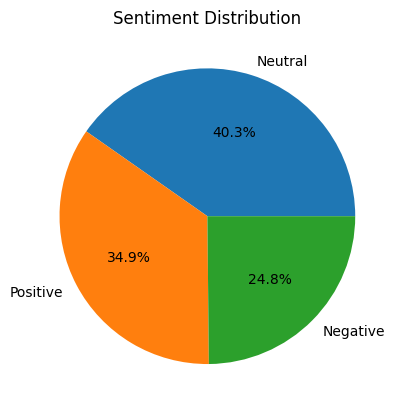

In [66]:
df['Sentiment'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.ylabel('')

plt.show()

In [67]:
negative_reviews = df[df['Sentiment'] == 'Negative']

negative_reviews[['Review Text']].head(10)

,Review Text
0,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and driver h...
2,I informed these reprobates that I WOULD NOT B...
3,I have bought from Amazon before and no proble...
5,Terrible you get customer service reps that ar...
8,I applied for a job with Amazon. I completed a...
12,Bought a Pitboss kc grill combo and received o...
14,Extremely disappointed in the customer service...
18,Amazon is the GARBAGE company ! When it comes ...
21,Bought a AIMOONSA 64gb MP3 player. Previous ha...


In [68]:
text = ' '.join(negative_reviews['Review Text'].dropna().astype(str))

In [69]:
from collections import Counter

words = text.lower().split()

negative_words = Counter(words)

print(negative_words.most_common(20))

[('the', 13097), ('to', 12923), ('i', 12178), ('and', 11041), ('a', 8391), ('they', 6661), ('my', 5528), ('amazon', 5485), ('for', 4446), ('it', 4370), ('is', 4346), ('of', 4343), ('not', 3825), ('was', 3660), ('have', 3633), ('that', 3449), ('on', 3421), ('in', 3087), ('with', 3053), ('you', 2978)]


In [70]:
df.to_csv(r"D:\hp\Task4_Sentiment_Output.csv", index=False)